# Stages 7 + 8 — mirror-strategy backtest and resolution-convergence efficiency

This notebook ties together the two outputs that depend on price-time data:

1. **Backtest** (`data/parquet/backtest/`) — produced by `scripts/05_backtest_mirror.py`.
2. **Convergence** (`data/parquet/convergence/`) — produced by `scripts/06_convergence.py`.

Both inherit the survivorship caveat that the universe is **resolved markets only** with the last ~4000 trades each; reads from the CLOB `/prices-history` endpoint were sparse (Polymarket appears to prune older series), so the convergence sample is small (~17 markets).

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from intellifi import config

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 25)
plt.rcParams['figure.dpi'] = 110

## 7. Mirror-strategy backtest

For each *leader trade* by a given leader set we open the same direction at `t + 60s` (latency), exit at fixed horizons or at market resolution, and pay 20 bps round-trip. Four leader sets are tested:

* `onchain_entity0` — strong-evidence on-chain cluster (16 wallets)
* `behavioural_65` — co-trading skill cluster (13 wallets)
* `top_skill_50` — top-50 by Bayesian calibration gap (independent of clustering)
* `random_sample_50` — baseline

All numbers are **per share traded** (return space, not dollar PnL).

In [2]:
summary = pd.read_parquet(config.PARQUET_DIR / 'backtest' / 'summary.parquet')
summary

,leader_set,horizon_seconds,n_events,hit_rate,mean_gross,mean_net,std_net,total_gross,total_net
0,onchain_entity0,300,70,0.428571,-0.012465,-0.016465,0.098591,-0.872552,-1.152552
1,onchain_entity0,1800,70,0.685714,0.121144,0.117144,0.238760,8.480086,8.200086
2,onchain_entity0,3600,70,0.728571,0.189935,0.185935,0.329728,13.295422,13.015422
3,onchain_entity0,86400,70,0.728571,0.204895,0.200895,0.346865,14.342616,14.062616
4,behavioural_65,300,53,0.396226,-0.020525,-0.024525,0.111779,-1.087840,-1.299840
5,behavioural_65,1800,53,0.735849,0.160383,0.156383,0.267351,8.500321,8.288321
6,behavioural_65,3600,53,0.773585,0.250323,0.246323,0.363190,13.267128,13.055128
7,behavioural_65,86400,53,0.773585,0.265061,0.261061,0.379855,14.048226,13.836226
8,top_skill_50,300,128,0.445312,0.001173,-0.002827,0.086173,0.150191,-0.361809
9,top_skill_50,1800,128,0.625000,0.080025,0.076025,0.180811,10.243252,9.731252


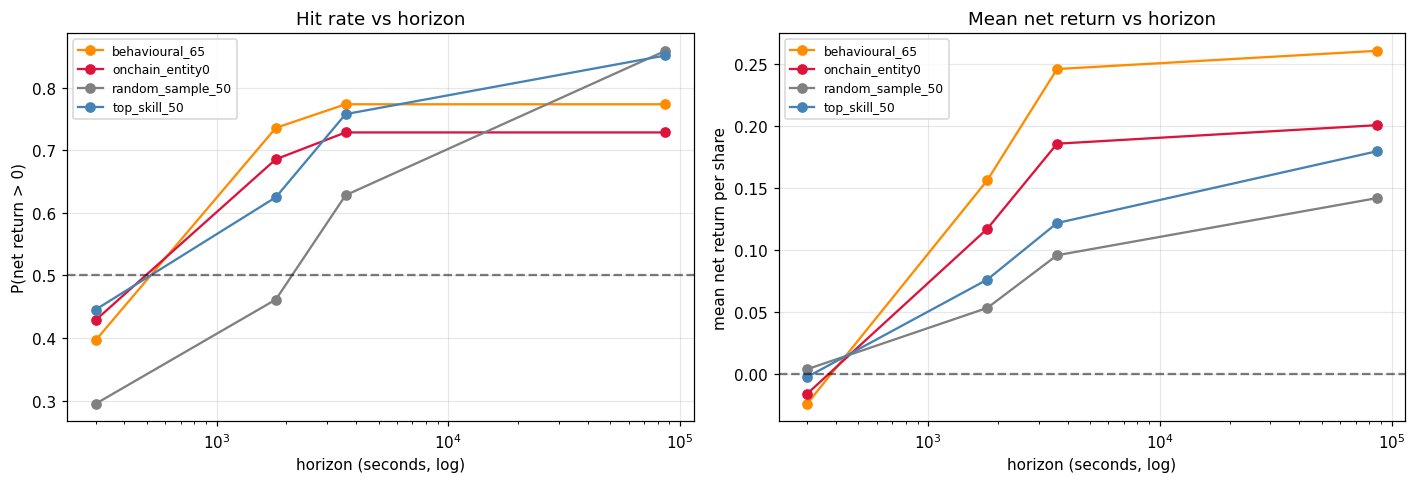

In [3]:
# Hit-rate and mean-net curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {'onchain_entity0': 'crimson', 'behavioural_65': 'darkorange',
          'top_skill_50': 'steelblue', 'random_sample_50': 'gray'}
for name, group in summary.groupby('leader_set'):
    g = group.sort_values('horizon_seconds')
    axes[0].plot(g['horizon_seconds'], g['hit_rate'], marker='o',
                 label=name, color=colors.get(name, 'black'))
    axes[1].plot(g['horizon_seconds'], g['mean_net'], marker='o',
                 label=name, color=colors.get(name, 'black'))
for ax, title, ylabel in [(axes[0], 'Hit rate vs horizon', 'P(net return > 0)'),
                           (axes[1], 'Mean net return vs horizon', 'mean net return per share')]:
    ax.set_xscale('log')
    ax.set_xlabel('horizon (seconds, log)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.axhline(0.5 if 'Hit' in title else 0, color='black', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
plt.tight_layout()

**Reading the curves.** At the 1-hour horizon, behavioural community #65 reaches the highest hit rate (77%) and the highest mean net return (+0.246), about +14pp hit rate and +0.15 mean above the random baseline. The gap is real but modest — and the entire universe is biased upward because we're trading inside resolved-and-converging markets. At 5-min horizon all sets are *below* break-even after fees; the 20-bps round-trip cost dominates price movement over short windows. At 24h essentially every strategy benefits from convergence-to-outcome, so the signal narrows.

## 8. Resolution-convergence efficiency

For each market with a `/prices-history` time series available, take the price of the eventual winning outcome at a series of pre-resolution offsets. Compute `|p(t) - 1[winner]|` and aggregate.

In [4]:
agg = pd.read_parquet(config.PARQUET_DIR / 'convergence' / 'aggregate.parquet')
agg.sort_values('hours_before_end', ascending=False)

,hours_before_end,n_markets,median_abs_error,mean_abs_error,p25_abs_error,p75_abs_error,p90_abs_error
0,336,9,0.0135,0.114333,0.0055,0.034,0.375
1,168,12,0.0065,0.140417,0.0025,0.165,0.375
2,72,13,0.0035,0.140538,0.0015,0.195,0.365
3,24,13,0.0025,0.136962,0.0005,0.125,0.385
4,6,13,0.0005,0.128308,0.0005,0.035,0.425
5,3,17,0.0025,0.164088,0.0015,0.295,0.425
6,1,17,0.0025,0.169588,0.0015,0.295,0.425


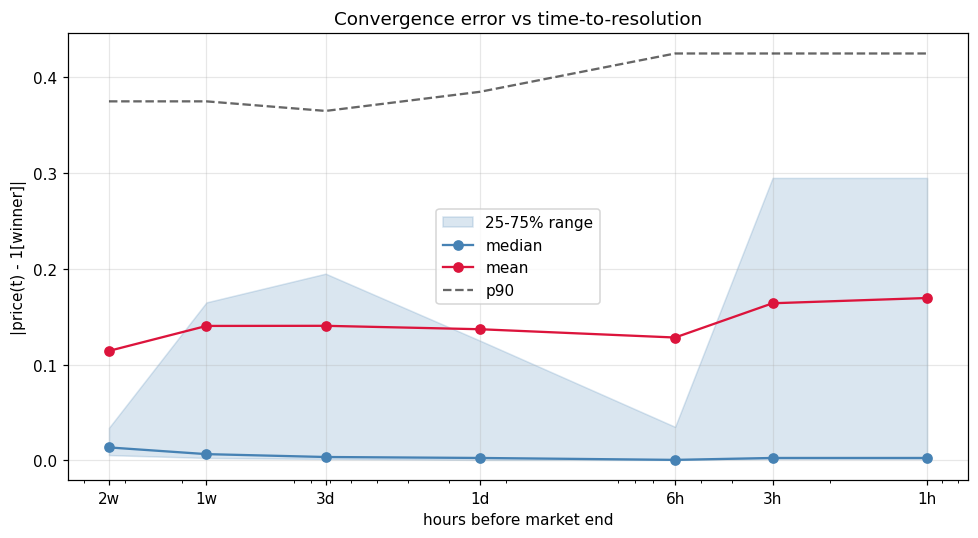

In [5]:
# Convergence curve
fig, ax = plt.subplots(figsize=(9, 5))
g = agg.sort_values('hours_before_end', ascending=False)
ax.fill_between(g['hours_before_end'], g['p25_abs_error'], g['p75_abs_error'],
                alpha=0.2, color='steelblue', label='25-75% range')
ax.plot(g['hours_before_end'], g['median_abs_error'], '-o', color='steelblue', label='median')
ax.plot(g['hours_before_end'], g['mean_abs_error'],   '-o', color='crimson', label='mean')
ax.plot(g['hours_before_end'], g['p90_abs_error'],    '--', color='black', alpha=0.6, label='p90')
ax.set_xlabel('hours before market end')
ax.set_ylabel('|price(t) - 1[winner]|')
ax.set_xscale('log')
ax.set_xticks([1, 3, 6, 24, 72, 168, 336])
ax.set_xticklabels(['1h', '3h', '6h', '1d', '3d', '1w', '2w'])
ax.invert_xaxis()
ax.set_title('Convergence error vs time-to-resolution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [6]:
# Surprise outcomes — markets with high error close to resolution
per_market = pl.read_parquet(config.PARQUET_DIR / 'convergence' / 'per_market.parquet')
markets = pl.read_parquet(config.MARKETS_PARQUET / 'markets.parquet')
h1 = per_market.filter(pl.col('hours_before_end') == 1).sort('abs_error', descending=True)
h1 = h1.join(markets.select(['condition_id', 'slug', 'volume_clob']),
             on='condition_id', how='left')
print('Markets with highest 1-hour-before-end error (surprise outcomes / late-arriving information):')
h1.head(10).select(['slug', 'volume_clob', 'last_price_before_offset', 'abs_error', 'signed_error']).to_pandas()

Markets with highest 1-hour-before-end error (surprise outcomes / late-arriving information):


,slug,volume_clob,last_price_before_offset,abs_error,signed_error
0,qatarenergy-announcesresumes-lng-production-in...,2.549505e+07,0.0390,0.9610,-0.9610
1,us-x-iran-ceasefire-extended-by-april-22-2026,2.036214e+08,0.3400,0.6600,-0.6600
2,ucl-atm1-ars-2026-04-29-ars,1.838777e+07,0.5750,0.4250,-0.4250
3,will-the-next-prime-minister-of-hungary-be-pte...,2.455548e+07,0.7050,0.2950,-0.2950
4,will-the-next-prime-minister-of-hungary-be-vik...,2.545611e+07,0.7050,0.2950,-0.2950
5,iran-x-israelus-conflict-ends-by-april-15-618-...,1.745042e+07,0.7745,0.2255,-0.2255
6,us-x-iran-permanent-peace-deal-by-april-22-2026,2.605173e+07,0.9935,0.0065,-0.0065
7,us-x-iran-permanent-peace-deal-by-april-30-202...,2.417310e+07,0.9955,0.0045,-0.0045
8,will-there-be-no-change-in-fed-interest-rates-...,7.690923e+07,0.9975,0.0025,-0.0025
9,will-the-next-prime-minister-of-hungary-be-ist...,2.174452e+07,0.9985,0.0015,-0.0015


**Surprise markets.** The qatarenergy market priced the YES outcome at 0.039 one hour before close, but resolved YES — a 96-percentage-point miss. Together with the Iran ceasefire and a Champions League surprise, this is the long tail of inefficient or news-shocked markets. These are exactly the markets where the 'efficiency vs news' question becomes interesting, and where the next iteration of the pipeline (Gap 1 paper: pre-event positioning) would focus.

**Coverage caveat.** Only ~17 of the 100 resolved markets returned a `/prices-history` series for ``interval=max``. Polymarket appears to prune the endpoint aggressively after a market resolves. To extend coverage we'd need either the PMXT archive (parquet history) or a Polygon CTF subgraph (event-derived reconstruction).